# 🩺 Diabetes Risk Classifier — v3 (XGBoost vs Random Forest)
**Dataset:** [Diabetes Prediction Dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset) — 100k rows with HbA1c & blood glucose lab values.


## 1. Install Dependencies

In [ ]:
!pip install xgboost imbalanced-learn scikit-learn pandas numpy joblib matplotlib seaborn -q
print('✅ Dependencies installed')

: 

## 2. Upload Dataset


In [2]:
from google.colab import files
import io, pandas as pd

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Saving diabetes_prediction_dataset.csv to diabetes_prediction_dataset.csv
✅ Loaded: 100,000 rows × 9 columns


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 3. Configuration

In [3]:
# ---- Config ----
TARGET_COL = 'diabetes'
TEST_RATIO = 0.2
SEED       = 42
USE_SMOTE  = True   # set False to skip oversampling
# ----------------

## 4. Preprocess Data + SMOTE

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Encode categorical columns (e.g. gender, smoking_history)
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    if col != TARGET_COL:
        df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

# Split features and target
X = df_enc.drop(columns=[TARGET_COL])
y = df_enc[TARGET_COL].astype(int)
feature_names = list(X.columns)

print(f'Features : {X.shape[1]}')
print(f'Samples  : {len(X):,}')
print('\nClass distribution (before SMOTE):')
vc = y.value_counts()
print(f'  No Diabetes : {vc.get(0, 0):,} ({vc.get(0,0)/len(y)*100:.1f}%)')
print(f'  Diabetes    : {vc.get(1, 0):,} ({vc.get(1,0)/len(y)*100:.1f}%)')

# Train/test split BEFORE SMOTE (never leak into test set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=SEED, stratify=y
)

# Impute then scale
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)
X_train_sc  = scaler.fit_transform(X_train_imp)
X_test_sc   = scaler.transform(X_test_imp)

# Apply SMOTE only on training data
if USE_SMOTE:
    smote = SMOTE(random_state=SEED)
    X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)
    print('\nClass distribution (after SMOTE):')
    vc2 = pd.Series(y_train_res).value_counts()
    print(f'  No Diabetes : {vc2.get(0,0):,}')
    print(f'  Diabetes    : {vc2.get(1,0):,}')
else:
    X_train_res, y_train_res = X_train_sc, y_train
    print('\nSMOTE skipped.')

Features : 8
Samples  : 100,000

Class distribution (before SMOTE):
  No Diabetes : 91,500 (91.5%)
  Diabetes    : 8,500 (8.5%)

Class distribution (after SMOTE):
  No Diabetes : 73,200
  Diabetes    : 73,200


## 5. Train Both Models

In [5]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# --- Random Forest ---
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)
rf_model.fit(X_train_res, y_train_res)
rf_pred = rf_model.predict(X_test_sc)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred, average='macro')
rf_cm   = confusion_matrix(y_test, rf_pred)
print(f'✅ Random Forest done — Accuracy: {rf_acc:.4f} | Macro F1: {rf_f1:.4f}')

# --- XGBoost ---
print('\nTraining XGBoost...')
# scale_pos_weight handles imbalance: ratio of negative to positive samples
neg, pos = np.bincount(y_train_res)
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=neg/pos,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0,
)
xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test_sc, y_test)],
    verbose=False,
)
xgb_pred = xgb_model.predict(X_test_sc)
xgb_acc  = accuracy_score(y_test, xgb_pred)
xgb_f1   = f1_score(y_test, xgb_pred, average='macro')
xgb_cm   = confusion_matrix(y_test, xgb_pred)
print(f'✅ XGBoost done    — Accuracy: {xgb_acc:.4f} | Macro F1: {xgb_f1:.4f}')

Training Random Forest...
✅ Random Forest done — Accuracy: 0.9473 | Macro F1: 0.8470

Training XGBoost...
✅ XGBoost done    — Accuracy: 0.9695 | Macro F1: 0.8911


## 6. Compare Models

Model                  Accuracy   Macro F1
---------------------------------------------
Random Forest            0.9473     0.8470
XGBoost                  0.9695     0.8911

🏆 Winner by Macro F1: XGBoost


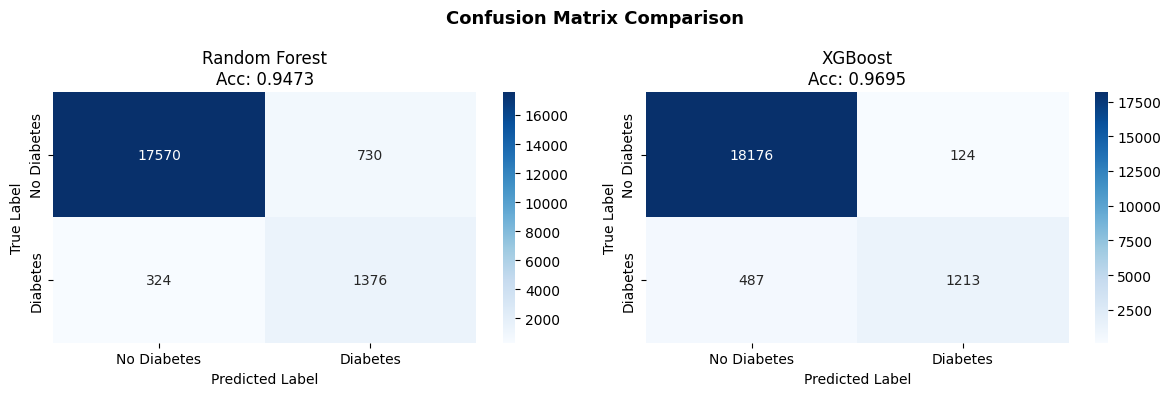

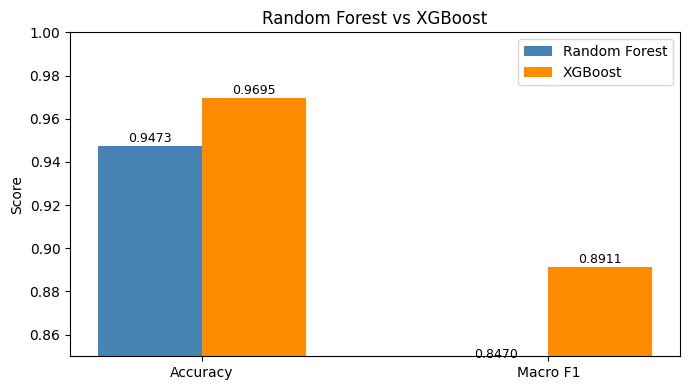


--- Random Forest ---
              precision    recall  f1-score   support

 No Diabetes       0.98      0.96      0.97     18300
    Diabetes       0.65      0.81      0.72      1700

    accuracy                           0.95     20000
   macro avg       0.82      0.88      0.85     20000
weighted avg       0.95      0.95      0.95     20000

--- XGBoost ---
              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     18300
    Diabetes       0.91      0.71      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.94      0.85      0.89     20000
weighted avg       0.97      0.97      0.97     20000



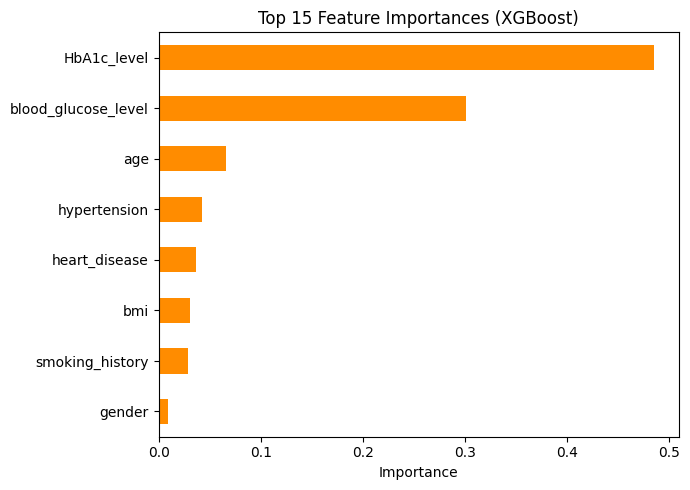

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = ['No Diabetes', 'Diabetes']

# ── Summary table ──
print('=' * 45)
print(f'{"Model":<20} {"Accuracy":>10} {"Macro F1":>10}')
print('-' * 45)
print(f'{"Random Forest":<20} {rf_acc:>10.4f} {rf_f1:>10.4f}')
print(f'{"XGBoost":<20} {xgb_acc:>10.4f} {xgb_f1:>10.4f}')
print('=' * 45)

winner_name = 'XGBoost' if xgb_f1 >= rf_f1 else 'Random Forest'
print(f'\n🏆 Winner by Macro F1: {winner_name}')

# ── Confusion matrices side by side ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cm, title in zip(axes,
                          [rf_cm, xgb_cm],
                          ['Random Forest', 'XGBoost']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'{title}\nAcc: {accuracy_score(y_test, rf_pred if title=="Random Forest" else xgb_pred):.4f}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
plt.suptitle('Confusion Matrix Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Bar chart comparison ──
fig, ax = plt.subplots(figsize=(7, 4))
metrics = ['Accuracy', 'Macro F1']
rf_vals  = [rf_acc,  rf_f1]
xgb_vals = [xgb_acc, xgb_f1]
x = np.arange(len(metrics))
width = 0.3
ax.bar(x - width/2, rf_vals,  width, label='Random Forest', color='steelblue')
ax.bar(x + width/2, xgb_vals, width, label='XGBoost',       color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Score')
ax.set_title('Random Forest vs XGBoost')
ax.legend()
for i, (rv, xv) in enumerate(zip(rf_vals, xgb_vals)):
    ax.text(i - width/2, rv + 0.002, f'{rv:.4f}', ha='center', fontsize=9)
    ax.text(i + width/2, xv + 0.002, f'{xv:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# ── Full classification reports ──
print('\n--- Random Forest ---')
print(classification_report(y_test, rf_pred, target_names=labels))
print('--- XGBoost ---')
print(classification_report(y_test, xgb_pred, target_names=labels))

# ── Feature importance of winner ──
best_model      = xgb_model if winner_name == 'XGBoost' else rf_model
importances     = pd.Series(best_model.feature_importances_, index=feature_names)
top_features    = importances.nlargest(15).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
top_features.plot(kind='barh', ax=ax,
                  color='darkorange' if winner_name == 'XGBoost' else 'steelblue')
ax.set_title(f'Top 15 Feature Importances ({winner_name})')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Save & Download the Best Model

In [7]:
import joblib

best_pred = xgb_pred if winner_name == 'XGBoost' else rf_pred
best_acc  = xgb_acc  if winner_name == 'XGBoost' else rf_acc
best_f1   = xgb_f1   if winner_name == 'XGBoost' else rf_f1
best_cm   = xgb_cm   if winner_name == 'XGBoost' else rf_cm

model_bundle = {
    'model_type'        : winner_name,
    'title'             : f'Diabetes Risk Classifier ({winner_name})',
    'description'       : 'Predicts diabetes status using clinical lab features.',
    'model'             : best_model,
    'imputer'           : imputer,
    'scaler'            : scaler,
    'features'          : feature_names,
    'classes'           : [{'value': 0, 'name': 'No_Diabetes'},
                            {'value': 1, 'name': 'Diabetes'}],
    'metrics'           : {
        'testRatio'      : TEST_RATIO,
        'testCount'      : len(y_test),
        'accuracy'       : best_acc,
        'macroF1'        : best_f1,
        'confusionMatrix': best_cm.tolist(),
        'rf_accuracy'    : rf_acc,
        'rf_macroF1'     : rf_f1,
        'xgb_accuracy'   : xgb_acc,
        'xgb_macroF1'    : xgb_f1,
    },
}

MODEL_PATH = f'diabetes_model_{winner_name.lower().replace(" ", "_")}.joblib'
joblib.dump(model_bundle, MODEL_PATH)
print(f'✅ Best model ({winner_name}) saved to {MODEL_PATH}')
print(f'   Accuracy : {best_acc:.4f}')
print(f'   Macro F1 : {best_f1:.4f}')
files.download(MODEL_PATH)

✅ Best model (XGBoost) saved to diabetes_model_xgboost.joblib
   Accuracy : 0.9695
   Macro F1 : 0.8911


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>